In [ ]:
!pip install -U bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.0 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0


In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        print("utils.py not found in any parent folder. Please upload.")
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig
import torch

In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_m',
                'quantization': 'full',
                'training_mode': 'few shot 15 examples',
                'model_id': 'google/flan-t5-xl'}

# Create checkpoint path
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


In [ ]:
utils.hf_login("HF_TOKEN")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForSeq2SeqLM.from_pretrained(
    global_params['model_id'],
    dtype=torch.float16,
    device_map="auto"
    )

# Change the model to evaluation mode
model.eval()
model.config.use_cache = True

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# Upload indices
files.upload()

NameError: name 'files' is not defined

In [ ]:
# Lock 15 examples to be used for few shot
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')

k = 15 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[:k]]
mnli_m_val_few_shot = mnli_m_val.drop(mnli_m_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 

Example 2
Premise: my goodness it's hard to believe i didn't think there was anybody in the country who hadn't seen that one
Hypothesis: I thought everyone in the US had already seen that movie. 
Answer: neutral 

Example 3
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 

Example 4
Premise: uh-huh well maybe well i've enjoyed talking to you okay bye-bye
Hypothesis: I liked talking to you.
Answer: entailment 

Example 5
Premise: Even if auditors do not follow such other standards and methodologies, they may still serve as a useful source of guidance to auditors in planning their work under GAGAS.
Hypothesi

In [ ]:
# Lock 1 opposite examples to be used for few shot
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')

k = 2 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[k]]
mnli_m_val_few_shot = mnli_m_val.drop(mnli_m_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 




In [ ]:
mnli_m_val_few_shot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2111 entries, 0 to 2125
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   premise                     2111 non-null   object
 1   hypothesis                  2111 non-null   object
 2   label                       2111 non-null   object
 3   hypothesis_graph_structure  2111 non-null   object
dtypes: object(4)
memory usage: 82.5+ KB


In [ ]:
mnli_m_val_few_shot.head(10)

,premise,hypothesis,label,hypothesis_graph_structure
0,Based on the list provided of the uses of subs...,"If a substance has a ph value greater than 7,t...",neutral,a substance<>has<>a ph value greater than 7
1,If one or two base pairs are change...,Invertebrates (and higher animals) can also be...,neutral,Invertebrates (and higher animals<>can be plac...
2,"At high temperatures, the solid dye converts i...",Gases and liquids become solids at low tempera...,neutral,Gases and liquids<>become<>solids
3,Chapter 11 Gas and Kinetic Theory .,The behavior of ideal gases is explained by ki...,neutral,The behavior of ideal gases<>is explained<>by ...
4,Both the continental crust and the oceanic cru...,Gabbro is a dark dense rock that can be found ...,neutral,Gabbro<>is<>a dark dense rock that can be foun...
5,The phylum for common marigolds is angiosperms.,Angiosperms are the most successful phylum of ...,neutral,Angiosperms<>are<>the most successful phylum o...
6,Lyme Disease is caused by a bacterium that's ...,Lyme disease is caused by bacteria.,entails,Lyme disease<>is caused<>by bacteria
7,Corolla Collective term for all the petals of ...,All of the petals together are called a corolla.,entails,All of the petals<>together are called<>a corolla
8,A polyploid is simply an organism that contain...,A(n) polyploid is an individual with more than...,entails,A(n) polyploid<>is<>an individual with more th...
9,Because type 1 diabetes is a relatively rare d...,Diabetes is unpreventable in the type one form...,neutral,Diabetes<>is<>unpreventable$$$it<>is<>of the s...


Token indices sequence length is longer than the specified maximum sequence length for this model (887 > 512). Running this sequence through the model will result in indexing errors


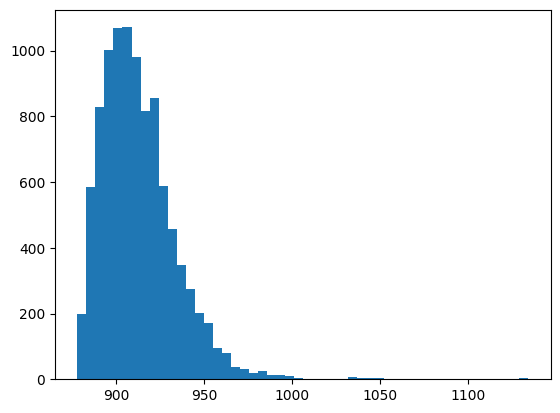

Max prompt length: 1134
Max label length: 4
Safe prompt_max_length: 1036 tokens
This would truncate 20 examples (0.204%) out of 9800


In [ ]:
# Find the max_length for tokenization to avoid wasting computing.
utils.find_max_length(mnli_m_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'],
                      chat_template=False, kind='few_shot', examples=prompt_examples)

In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset(dataframe=mnli_m_val_few_shot,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=1036,
                               label_max_length=4,
                               kind='few_shot',
                               chat_template=False,
                               examples=prompt_examples)

batch_size = 32 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [ ]:
# Iter for 1 batch
batch = next(iter(dataloader))
input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
gold_labels_batch = batch["labels"] # Keep to CPU

# Get predicted labels
predictions = utils.get_flant5_preds_text_gen(input_ids_batch, attention_mask_batch, model, tokenizer)

# Print each prediction with its gold label and probabilities
for i, (pred, gold) in enumerate(zip(predictions, gold_labels_batch)):
    print(f"{i+1}: Predicted: {pred}  |  Gold: {gold}")

1: Predicted: Answer: neutral  |  Gold: neutral
2: Predicted: Answer: neutral  |  Gold: contradiction
3: Predicted: Answer: neutral  |  Gold: entailment
4: Predicted: Answer: neutral  |  Gold: contradiction
5: Predicted: Answer: neutral  |  Gold: contradiction
6: Predicted: Answer: neutral  |  Gold: contradiction
7: Predicted: Answer: neutral  |  Gold: contradiction
8: Predicted: Answer: neutral  |  Gold: neutral
9: Predicted: Answer: neutral  |  Gold: contradiction
10: Predicted: Answer: neutral  |  Gold: neutral
11: Predicted: Answer: neutral  |  Gold: contradiction
12: Predicted: Answer: neutral  |  Gold: contradiction
13: Predicted: Answer: neutral  |  Gold: contradiction
14: Predicted: Answer: neutral  |  Gold: entailment
15: Predicted: Answer: neutral  |  Gold: neutral
16: Predicted: Answer: neutral  |  Gold: entailment
17: Predicted: Answer: neutral  |  Gold: entailment
18: Predicted: Answer: neutral  |  Gold: entailment
19: Predicted: Answer: neutral  |  Gold: neutral
20: Predi

In [ ]:
# Print example prompt
print(dataset_test[0]["prompt"])

Examples:
Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 

Example 2
Premise: my goodness it's hard to believe i didn't think there was anybody in the country who hadn't seen that one
Hypothesis: I thought everyone in the US had already seen that movie. 
Answer: neutral 

Example 3
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 

Example 4
Premise: uh-huh well maybe well i've enjoyed talking to you okay bye-bye
Hypothesis: I liked talking to you.
Answer: entailment 

Example 5
Premise: Even if auditors do not follow such other standards and methodologies, they may still serve as a useful source of guidance to auditors in planning their work under GAGAS.

In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch", position=0, leave=True)):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_pred_labels = utils.get_flant5_preds_text_gen(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      model=model,
                                      tokenizer=tokenizer)


        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(batch["labels"].tolist() if torch.is_tensor(batch["labels"]) else batch["labels"])

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   0%|          | 1/307 [00:04<20:52,  4.09s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


Evaluating:  17%|█▋        | 51/307 [03:01<15:07,  3.54s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


...

Checkpoint saved: 251, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


Evaluating:  98%|█████████▊| 301/307 [17:47<00:21,  3.55s/batch]

Checkpoint saved: 301, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


Evaluating: 100%|██████████| 307/307 [18:06<00:00,  3.54s/batch]

Checkpoint saved: 307, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt


In [ ]:
unique_labels = set(predicted_labels)
print(unique_labels)

{'contradiction', 'neutral', 'entailment'}


In [ ]:
predicted_labels_clean = []

for label in predicted_labels:
    if 'neutral' in label:
        label = 'neutral'
    elif 'entail' in label:
        label = 'entailment'
    elif 'contradict' in label:
        label = 'contradiction'

    predicted_labels_clean.append(label)

In [ ]:
unique_labels = set(predicted_labels_clean)
print(unique_labels)

{'neutral', 'contradiction', 'entailment'}


Checkpoint found.
Accuracy: 0.8382.
 Precision: 0.8515.
Recall: 0.8386.
F1 Score: 0.8396.
 Matthew's Correlation Coefficient: 0.7625.
 Cohen's Kappa Score: 0.7575.


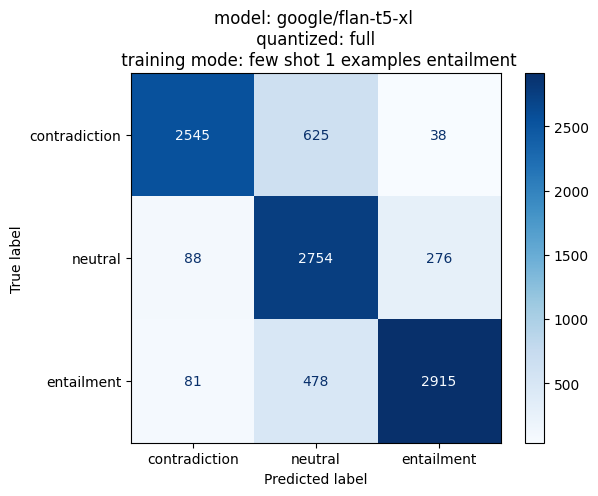

In [ ]:
# Calculate metrics with 1 examples - entailment - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8444.
 Precision: 0.8482.
Recall: 0.8416.
F1 Score: 0.8430.
 Matthew's Correlation Coefficient: 0.7677.
 Cohen's Kappa Score: 0.7660.


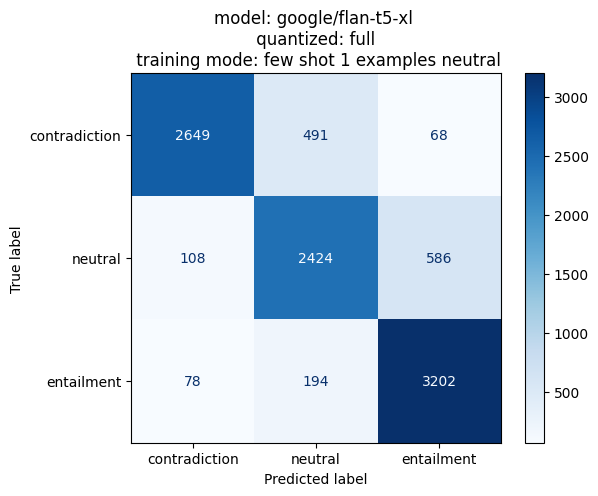

In [ ]:
# Calculate metrics with 1 examples - neutral - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8344.
 Precision: 0.8416.
Recall: 0.8324.
F1 Score: 0.8340.
 Matthew's Correlation Coefficient: 0.7536.
 Cohen's Kappa Score: 0.7512.


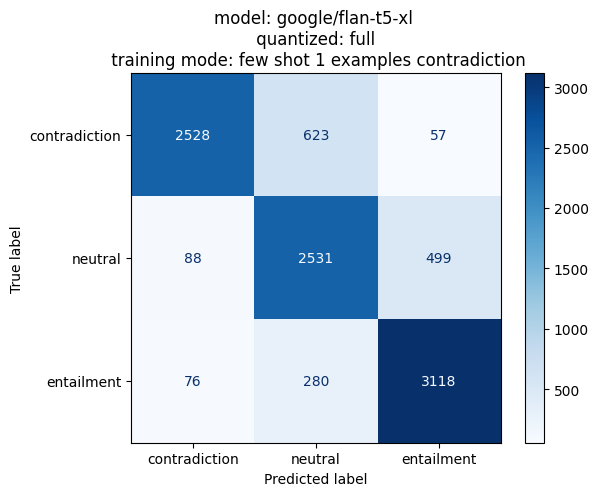

In [ ]:
# Calculate metrics with 1 examples - contradiction - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8605.
 Precision: 0.8651.
Recall: 0.8605.
F1 Score: 0.8610.
 Matthew's Correlation Coefficient: 0.7926.
 Cohen's Kappa Score: 0.7908.


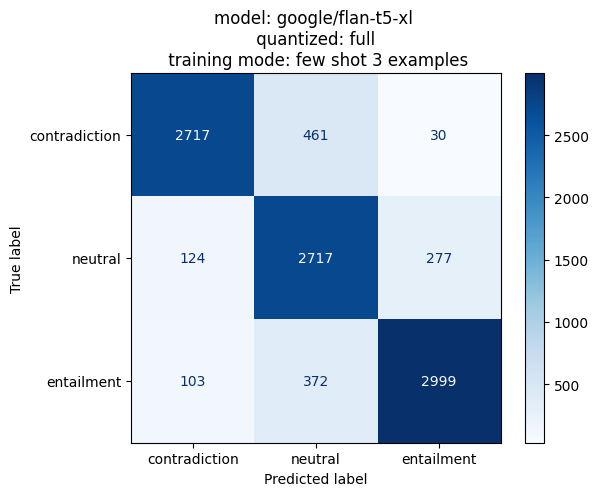

In [ ]:
# Calculate metrics with 3 examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8107.
 Precision: 0.8323.
Recall: 0.8126.
F1 Score: 0.8137.
 Matthew's Correlation Coefficient: 0.7254.
 Cohen's Kappa Score: 0.7168.


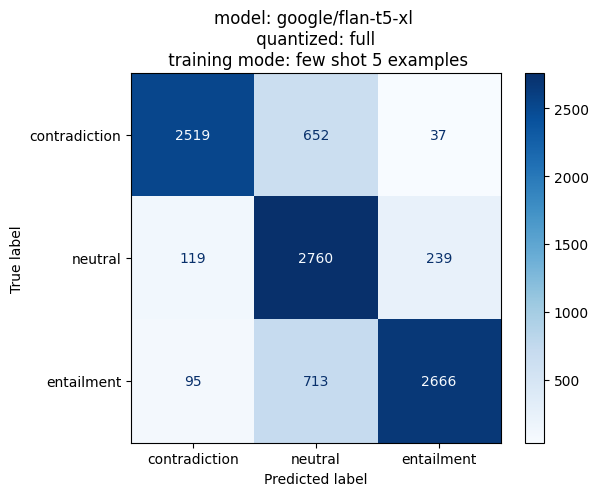

In [ ]:
# Calculate metrics with 5 examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
predicted_labels_clean = []

for label in predicted_labels:
    if 'neutral' in label:
        label = 'neutral'
    elif 'entail' in label:
        label = 'entailment'
    elif 'contradict' in label:
        label = 'contradiction'

    predicted_labels_clean.append(label)
utils.evaluate_metrics(predicted_labels=predicted_labels_clean, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8519.
 Precision: 0.8615.
Recall: 0.8530.
F1 Score: 0.8533.
 Matthew's Correlation Coefficient: 0.7821.
 Cohen's Kappa Score: 0.7782.


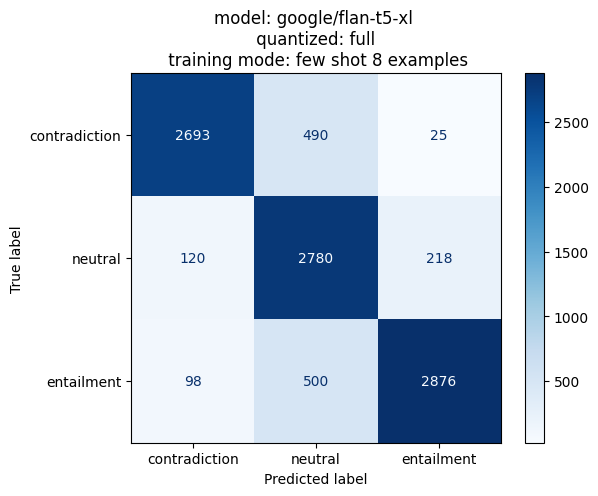

In [ ]:
# Calculate metrics with 8 examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8469.
 Precision: 0.8584.
Recall: 0.8477.
F1 Score: 0.8484.
 Matthew's Correlation Coefficient: 0.7752.
 Cohen's Kappa Score: 0.7707.


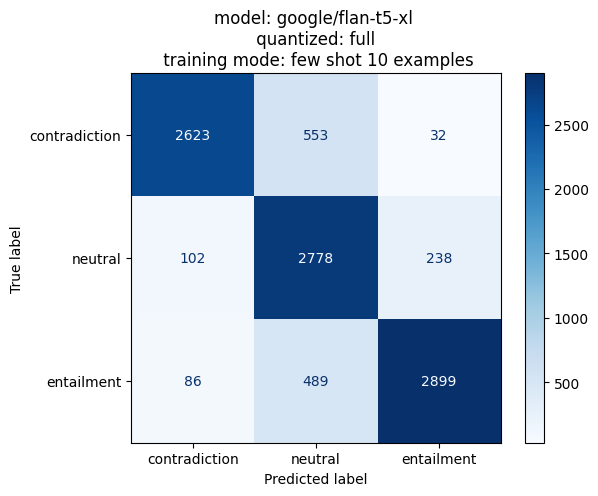

In [ ]:
# Calculate metrics with 10 examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8503.
 Precision: 0.8598.
Recall: 0.8509.
F1 Score: 0.8516.
 Matthew's Correlation Coefficient: 0.7794.
 Cohen's Kappa Score: 0.7757.


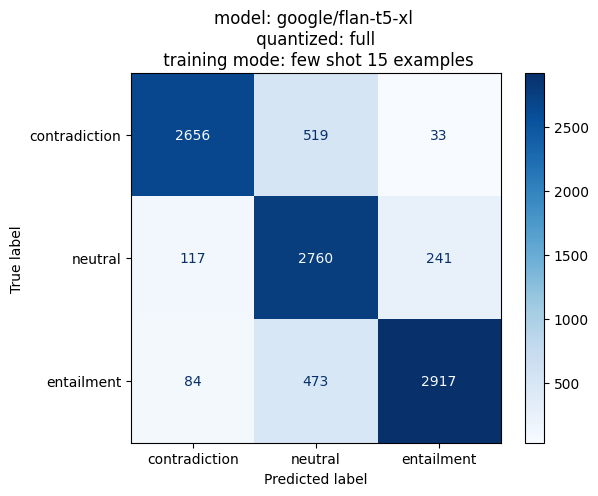

In [ ]:
# Calculate metrics with 15 examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

# <center> Now to test the mismatched validation set separately. <center>

In [ ]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_mm',
                'quantization': 'full',
                'training_mode': 'few shot 15 mm examples',
                'model_id': 'google/flan-t5-xl'}

# Create checkpoint path
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


In [ ]:
idx = files.upload()

Saving mnli_mm_few_shot_example_idx.npy to mnli_mm_few_shot_example_idx.npy


In [ ]:
# Use mnli_m examples to test few shot on mnli_mm
# Lock 1 examples to be used for few shot
# files.upload()

# Load mnli_mm_val
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

# Load and get examples from mnli_m_val
demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

k = 1 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[:k]]

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Saving mnli_mm_val.csv to mnli_mm_val.csv
Example 1
Premise: yeah no i don't know if there's any any series that i pay attention to i try to watch Cheers once in a while
Hypothesis: I watch Cheers everynow and then, but I don't watch many series.
Answer: entailment 




In [ ]:
# Lock 1 opposite examples from mnli_m to be used for few shot on mnli_mm
# files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')
mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_m_few_shot_example_idx.npy')

k = 2 # Examples to lock
demo_examples = mnli_m_val.iloc[demo_idxs[k]]

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: In addition, Saracens invaded the Provencal coast from North Africa, and Magyar armies attacked Lor?­raine and Bur?­gun?­dy.
Hypothesis: The Magyar armies did not attack anyone.
Answer: contradiction 




In [ ]:
# Lock 15 mnli_mm examples to be used for few shot on mnli_mm
# files.upload()
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_mm_few_shot_example_idx.npy')

k = 15 # Examples to lock
demo_examples = mnli_mm_val.iloc[demo_idxs[:k]]
mnli_mm_val_few_shot = mnli_mm_val.drop(mnli_mm_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
for i in range(len(demo_examples)):
    prompt_examples += f"Example {i+1}\nPremise: {demo_examples.iloc[i]['premise']}\nHypothesis: {demo_examples.iloc[i]['hypothesis']}\nAnswer: {demo_examples.iloc[i]['label']} \n\n"

print(prompt_examples)

Example 1
Premise: The idiom dressed to the nines could be from Middle English dressed to then eynes `dressed to the eyes.
Hypothesis: The Middle English had a similar idiom.
Answer: entailment 

Example 2
Premise: Make checks payable to Indiana University Foundation.
Hypothesis: If checks are not written to Indiana University Foundation, there will be an issue.
Answer: neutral 

Example 3
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 

Example 4
Premise: You got a job cutting siding wasn't it?
Hypothesis: I heard you got a job as a gravedigger.
Answer: contradiction 

Example 5
Premise: In the Roman Catholic Church, for example, women can function as acolytes (one of the minor orders of the diaconate) but may not be officially installed as acolytes.
H

In [ ]:
# Lock 1 opposite examples to be used for few shot
# files.upload()
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')
mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

demo_idxs = np.load('mnli_mm_few_shot_example_idx.npy')

k = 2 # Examples to lock
demo_examples = mnli_mm_val.iloc[demo_idxs[k]]
mnli_mm_val_few_shot = mnli_mm_val.drop(mnli_mm_val.index[demo_idxs])

# Make examples for prompt
prompt_examples = ''
prompt_examples += f"Example 1\nPremise: {demo_examples['premise']}\nHypothesis: {demo_examples['hypothesis']}\nAnswer: {demo_examples['label']} \n\n"

print(prompt_examples)

Example 1
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 




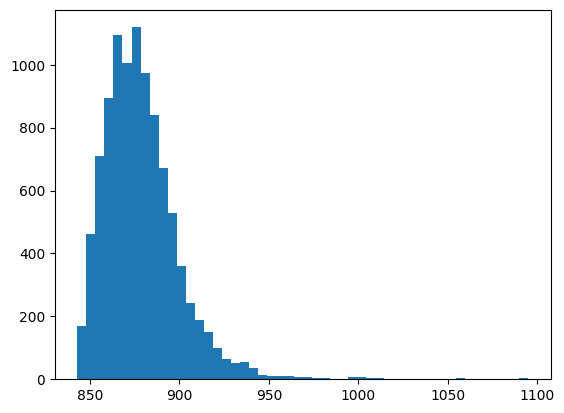

Max prompt length: 1095
Max label length: 4
Safe prompt_max_length: 1002 tokens
This would truncate 19 examples (0.194%) out of 9817


In [ ]:
# Plot a histogram to find max_length of tokens
utils.find_max_length(mnli_mm_val_few_shot, tokenizer=tokenizer, dataset_type=global_params['dataset_type'], chat_template=False, examples=prompt_examples, kind='few_shot')

In [ ]:
# Define dataset and create a dataloader.
dataset_test_mm = utils.MyDataset(dataframe=mnli_mm_val_few_shot,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=1002,
                               label_max_length=4,
                               kind='few_shot',
                               chat_template=False,
                               examples=prompt_examples)

batch_size = 64 # Change batch size according to GPU
dataloader_mm = DataLoader(dataset_test_mm, batch_size=batch_size, shuffle=False)

In [ ]:
# Show an example prompt
print(dataset_test_mm[0]['prompt'])

Examples:
Example 1
Premise: The idiom dressed to the nines could be from Middle English dressed to then eynes `dressed to the eyes.
Hypothesis: The Middle English had a similar idiom.
Answer: entailment 

Example 2
Premise: Make checks payable to Indiana University Foundation.
Hypothesis: If checks are not written to Indiana University Foundation, there will be an issue.
Answer: neutral 

Example 3
Premise: As early as 1 1/2 to 2 years, children begin to talk about the past, guided by adults who prompt them and expand on their fragmented recollections.
Hypothesis: Even when prompted by adults who are guiding them, children will never talk about the past. 
Answer: contradiction 

Example 4
Premise: You got a job cutting siding wasn't it?
Hypothesis: I heard you got a job as a gravedigger.
Answer: contradiction 

Example 5
Premise: In the Roman Catholic Church, for example, women can function as acolytes (one of the minor orders of the diaconate) but may not be officially installed as a

In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader_mm, desc="Evaluating", unit="batch", position=0, leave=True)):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_pred_labels = get_flant5_preds_text_gen(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      model=model,
                                      tokenizer=tokenizer)


        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(batch["labels"].tolist() if torch.is_tensor(batch["labels"]) else batch["labels"])

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader_mm) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

No checkpoint found.


Evaluating:   1%|          | 1/154 [00:07<18:44,  7.35s/batch]

Checkpoint saved: 1, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


Evaluating:  33%|███▎      | 51/154 [05:51<11:49,  6.89s/batch]

Checkpoint saved: 51, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


...

Checkpoint saved: 101, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


Evaluating:  98%|█████████▊| 151/154 [17:20<00:20,  6.89s/batch]

Checkpoint saved: 151, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


Evaluating: 100%|██████████| 154/154 [17:36<00:00,  6.86s/batch]

Checkpoint saved: 154, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt


In [ ]:
unique_labels = set(predicted_labels)
print(unique_labels)

{'neutral', 'contradiction', 'entailment'}


In [ ]:
from collections import Counter

predicted_labels, gold_labels, batch_no = utils.load_checkpoint(checkpoint_path)

label_mapping = {
    "yes": "entailment"
}

def clean_prediction(text):
    text = str(text).lower().strip()

    if text.startswith("answer:"):
        text = text.replace("answer:", "").strip()
    return label_mapping.get(text, text)

cleaned_preds = [clean_prediction(p) for p in predicted_labels]

counts = Counter(cleaned_preds)
print("--- Cleaned Label Distribution ---")
for label, count in counts.items():
    print(f"{label}: {count}")

torch.save({
    "predicted_labels": cleaned_preds,
    "gold_labels": gold_labels,
    "batch_no": batch_no
}, checkpoint_path)

Checkpoint found.
--- Cleaned Label Distribution ---
contradiction: 2969
entailment: 3342
neutral: 3506


Checkpoint found.
Accuracy: 0.8431.
 Precision: 0.8537.
Recall: 0.8428.
F1 Score: 0.8440.
 Matthew's Correlation Coefficient: 0.7685.
 Cohen's Kappa Score: 0.7647.


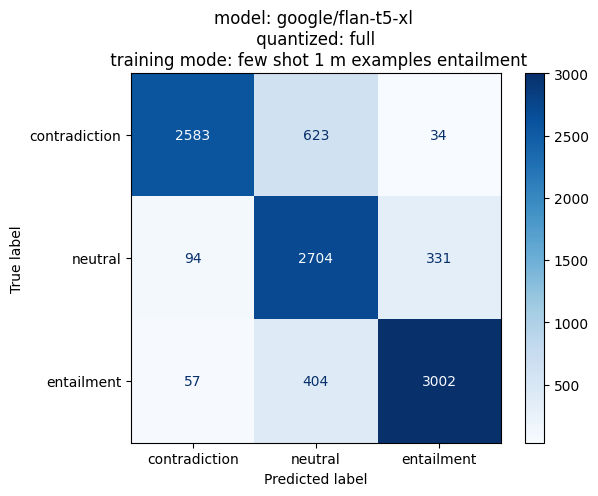

In [ ]:
# Calculate metrics for 1 m examples - entailment - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8437.
 Precision: 0.8486.
Recall: 0.8405.
F1 Score: 0.8418.
 Matthew's Correlation Coefficient: 0.7675.
 Cohen's Kappa Score: 0.7648.


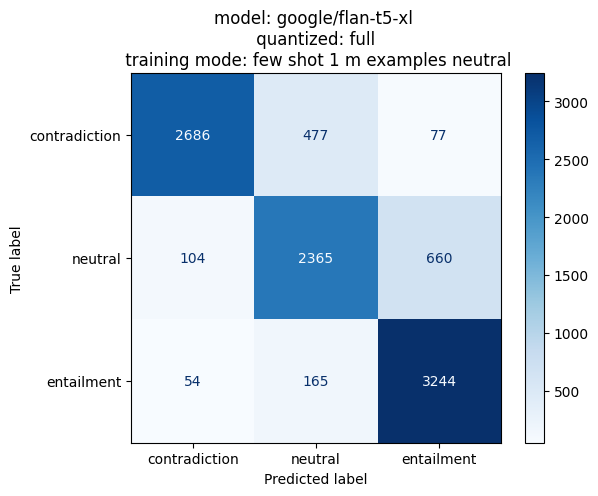

In [ ]:
# Calculate metrics for 1 m examples - neutral - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
predicted_labels_clean = []

for label in predicted_labels:
    if 'neutral' in label:
        label = 'neutral'
    elif 'yes' in label:
        label = 'entailment'
    elif 'contradict' in label:
        label = 'contradiction'

    predicted_labels_clean.append(label)
utils.evaluate_metrics(predicted_labels=predicted_labels_clean, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8367.
 Precision: 0.8433.
Recall: 0.8342.
F1 Score: 0.8355.
 Matthew's Correlation Coefficient: 0.7571.
 Cohen's Kappa Score: 0.7545.


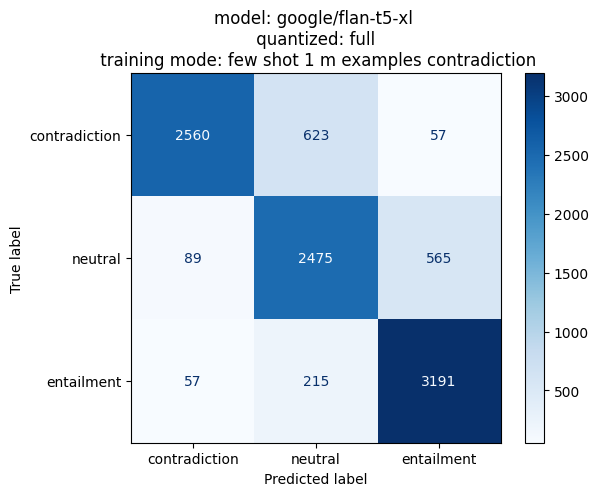

In [ ]:
# Calculate metrics for 1 m examples - contradiction - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
predicted_labels_clean = []

for label in predicted_labels:
    if 'neutral' in label:
        label = 'neutral'
    elif 'yes' in label:
        label = 'entailment'
    elif 'contradict' in label:
        label = 'contradiction'

    predicted_labels_clean.append(label)
utils.evaluate_metrics(predicted_labels=predicted_labels_clean, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8489.
 Precision: 0.8553.
Recall: 0.8485.
F1 Score: 0.8495.
 Matthew's Correlation Coefficient: 0.7756.
 Cohen's Kappa Score: 0.7734.


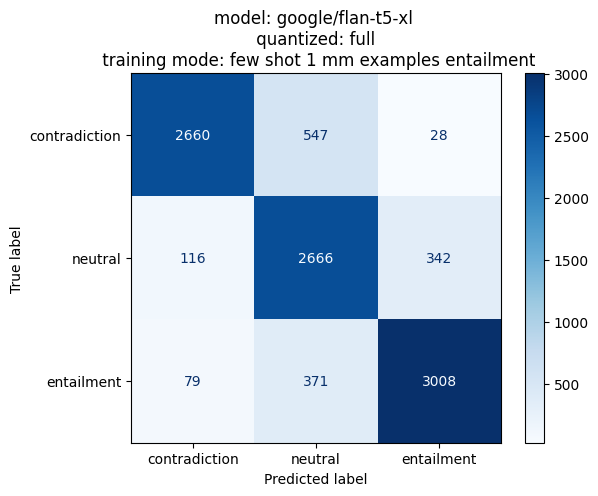

In [ ]:
# Calculate metrics for 1 mm examples - entailment - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8351.
 Precision: 0.8418.
Recall: 0.8335.
F1 Score: 0.8350.
 Matthew's Correlation Coefficient: 0.7545.
 Cohen's Kappa Score: 0.7524.


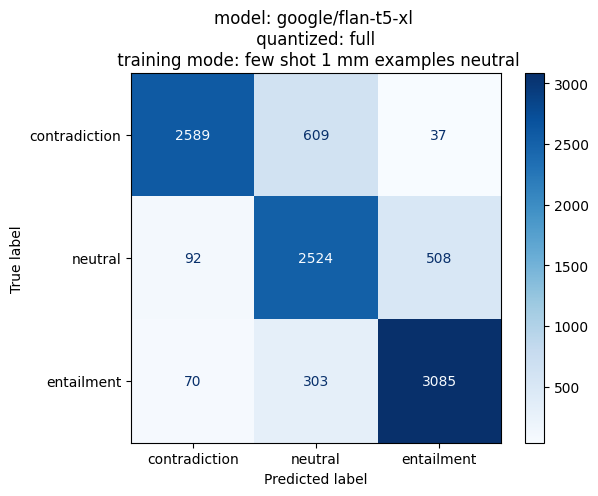

In [ ]:
# Calculate metrics for 1 mm examples - neutral - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
predicted_labels_clean = []

for label in predicted_labels:
    if 'neutral' in label:
        label = 'neutral'
    elif 'yes' in label:
        label = 'entailment'
    elif 'contradict' in label:
        label = 'contradiction'

    predicted_labels_clean.append(label)
utils.evaluate_metrics(predicted_labels=predicted_labels_clean, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8400.
 Precision: 0.8476.
Recall: 0.8379.
F1 Score: 0.8392.
 Matthew's Correlation Coefficient: 0.7624.
 Cohen's Kappa Score: 0.7596.


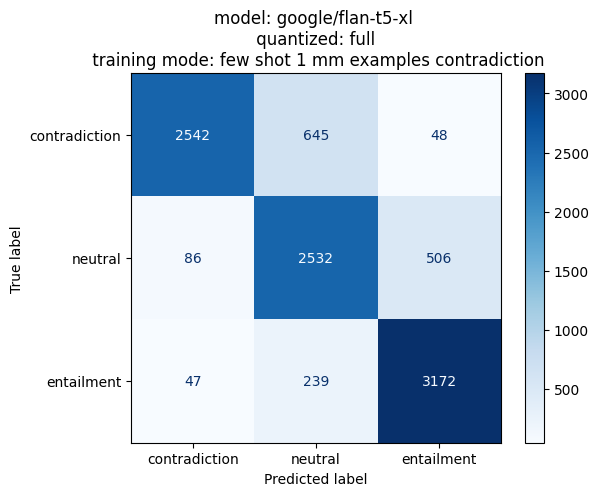

In [ ]:
# Calculate metrics for 1 mm examples - contradiction - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8597.
 Precision: 0.8637.
Recall: 0.8594.
F1 Score: 0.8600.
 Matthew's Correlation Coefficient: 0.7911.
 Cohen's Kappa Score: 0.7896.


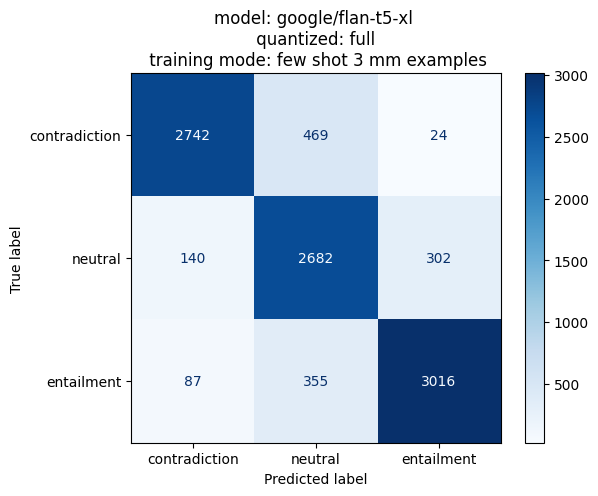

In [ ]:
# Calculate metrics for 3 mm examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8585.
 Precision: 0.8640.
Recall: 0.8581.
F1 Score: 0.8589.
 Matthew's Correlation Coefficient: 0.7897.
 Cohen's Kappa Score: 0.7878.


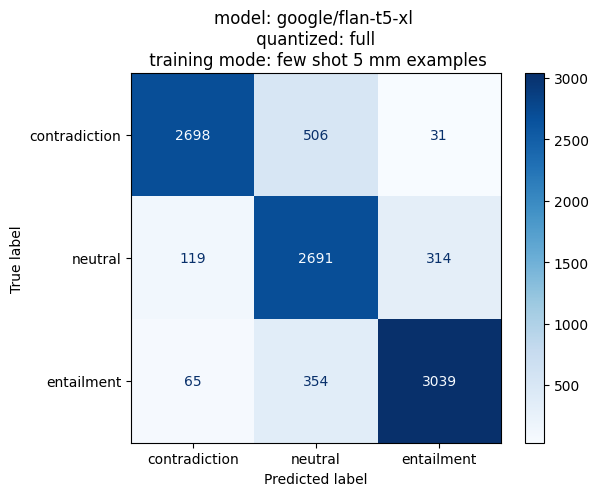

In [ ]:
# Calculate metrics for 5 mm examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8579.
 Precision: 0.8641.
Recall: 0.8574.
F1 Score: 0.8584.
 Matthew's Correlation Coefficient: 0.7890.
 Cohen's Kappa Score: 0.7869.


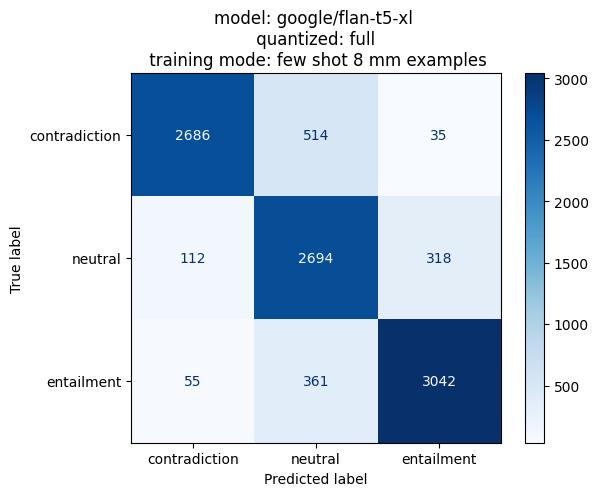

In [ ]:
# Calculate metrics for 8 mm examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8528.
 Precision: 0.8607.
Recall: 0.8524.
F1 Score: 0.8535.
 Matthew's Correlation Coefficient: 0.7820.
 Cohen's Kappa Score: 0.7793.


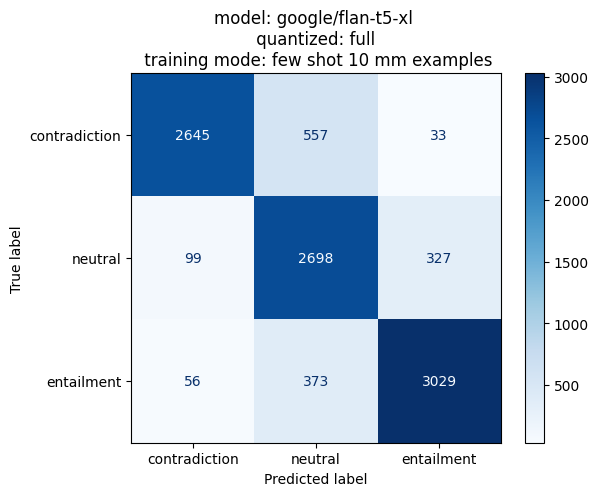

In [ ]:
# Calculate metrics for 10 mm examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

Checkpoint found.
Accuracy: 0.8542.
 Precision: 0.8594.
Recall: 0.8536.
F1 Score: 0.8546.
 Matthew's Correlation Coefficient: 0.7830.
 Cohen's Kappa Score: 0.7813.


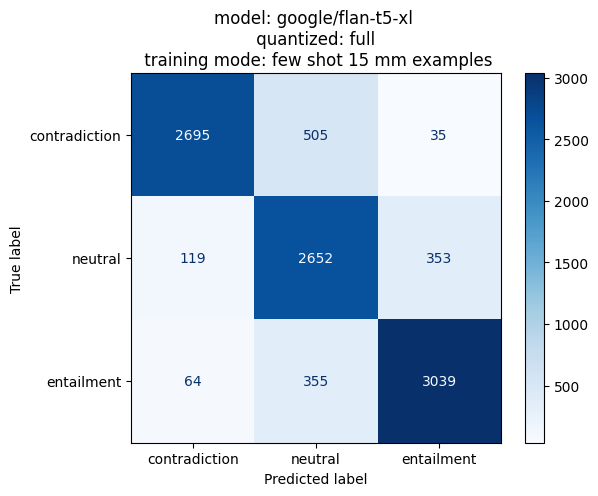

In [ ]:
# Calculate metrics for 15 mm examples - without chat template
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)